In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
features = pd.read_csv("features.csv")
train = pd.read_csv("train.csv")
store = pd.read_csv("stores.csv")

In [3]:
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [4]:
df = pd.merge(train, features, on=["Store","Date","IsHoliday"], how="left")

In [5]:
df = pd.merge(df, store, on="Store", how="left")

In [6]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [8]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

In [9]:
df.describe()

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
std,12.785297,30.492054,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000


In [10]:
df[["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]].isnull().mean()*100

MarkDown1    64.257181
MarkDown2    73.611025
MarkDown3    67.480845
MarkDown4    67.984676
MarkDown5    64.079038
dtype: float64

In [11]:
df.drop(columns=['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5'], axis=1, inplace=True)

In [12]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,A,151315


In [13]:
df["Date"] = pd.to_datetime(df["Date"])

In [14]:
df['Year'] = df["Date"].dt.year
df['Month'] = df["Date"].dt.month
df['Day'] = df["Date"].dt.day

In [15]:
df = df.rename({"Size":"Size (sqft)"}, axis=1)

In [16]:
df['IsHoliday'] = df['IsHoliday'].astype(int)

In [17]:
df = df.sort_values(by=["Store","Dept","Date"], ascending=True).reset_index(drop=True)

In [18]:
df = df.drop(columns=['Date'], axis=1)

<Axes: xlabel='Weekly_Sales'>

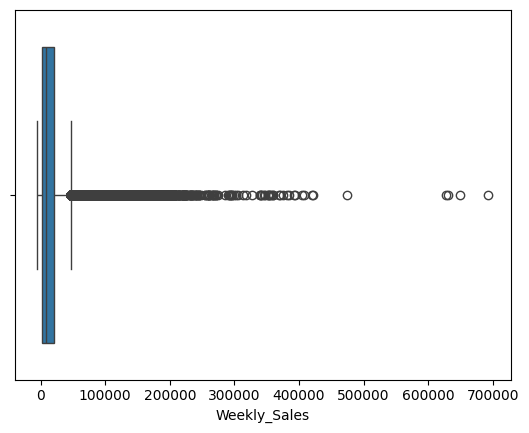

In [19]:
sns.boxplot(x=df["Weekly_Sales"])

In [20]:
df["Weekly_Sales"].describe(percentiles=[0.90,0.95,0.99])

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
50%        7612.030000
90%       42845.673000
95%       61201.951000
99%      106479.586000
max      693099.360000
Name: Weekly_Sales, dtype: float64

In [21]:
df[df['Weekly_Sales'] >= 600000]

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size (sqft),Year,Month,Day
95373,10,72,693099.36,1,55.33,3.162,126.669267,9.003,B,126512,2010,11,26
95425,10,72,630999.19,1,60.68,3.760,129.836400,7.874,B,126512,2011,11,25
337961,35,72,627962.93,1,46.67,3.039,136.689571,8.763,B,103681,2010,11,26
338013,35,72,649770.18,1,47.88,3.492,140.421786,8.745,B,103681,2011,11,25


In [22]:
df = df[df["Weekly_Sales"]>0]

In [23]:
df = df[['Store', 'Dept','Day','Month','Year', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'Type', 'Size (sqft)','Weekly_Sales']]

In [24]:
df

,Store,Dept,Day,Month,Year,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size (sqft),Weekly_Sales
0,1,1,5,2,2010,0,42.31,2.572,211.096358,8.106,A,151315,24924.50
1,1,1,12,2,2010,1,38.51,2.548,211.242170,8.106,A,151315,46039.49
2,1,1,19,2,2010,0,39.93,2.514,211.289143,8.106,A,151315,41595.55
3,1,1,26,2,2010,0,46.63,2.561,211.319643,8.106,A,151315,19403.54
4,1,1,5,3,2010,0,46.50,2.625,211.350143,8.106,A,151315,21827.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,28,9,2012,0,64.88,3.997,192.013558,8.684,B,118221,508.37
421566,45,98,5,10,2012,0,64.89,3.985,192.170412,8.667,B,118221,628.10
421567,45,98,12,10,2012,0,54.47,4.000,192.327265,8.667,B,118221,1061.02
421568,45,98,19,10,2012,0,56.47,3.969,192.330854,8.667,B,118221,760.01


In [25]:
rolling_mean_3 = df.groupby(["Store","Dept"])["Weekly_Sales"].transform(lambda x: x.shift(1).rolling(window=3).mean())

In [26]:
rolling_mean_7 = df.groupby(["Store","Dept"])["Weekly_Sales"].transform(lambda x: x.shift(1).rolling(window=7).mean())

In [27]:
lag_1 = df.groupby(["Store","Dept"])["Weekly_Sales"].transform(lambda x:x.shift(1))

In [28]:
df["Rolling_mean_3"] = rolling_mean_3
df["Rolling_mean_7"] = rolling_mean_7
df["Lag_1"] = lag_1

In [29]:
df = df.dropna().reset_index(drop=True)

<Axes: >

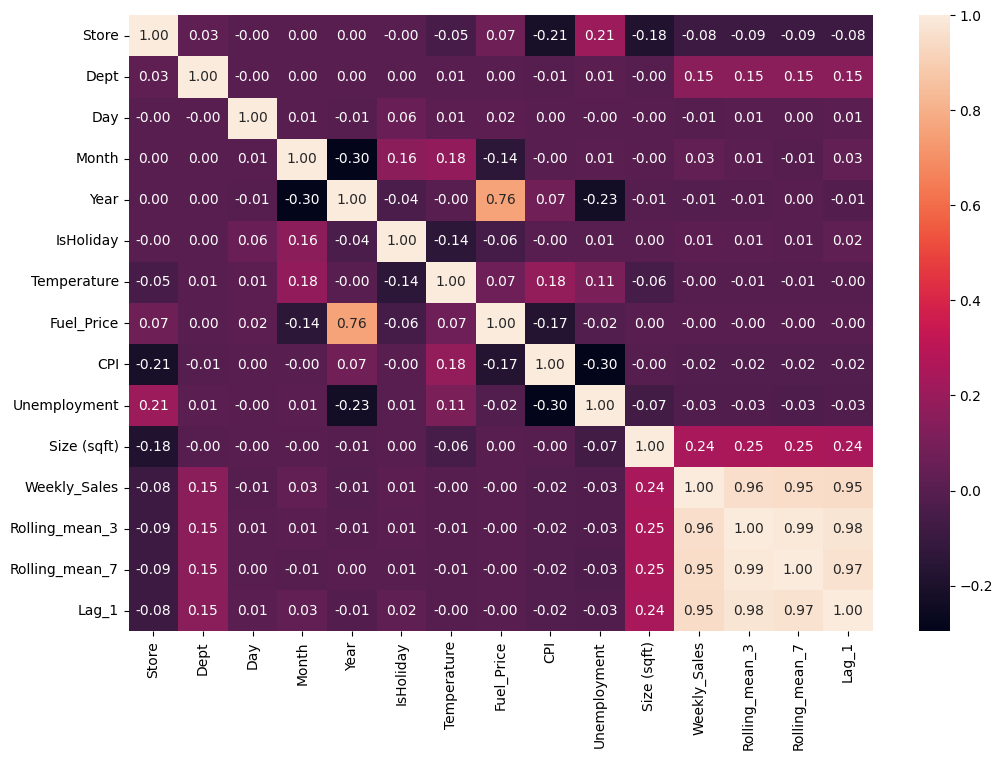

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")

In [31]:
train = df[df['Year'] < 2012]
test = df[df['Year'] >= 2012]

In [32]:
train

,Store,Dept,Day,Month,Year,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size (sqft),Weekly_Sales,Rolling_mean_3,Rolling_mean_7,Lag_1
0,1,1,26,3,2010,0,51.45,2.732,211.018042,8.106,A,151315,26229.21,21669.310000,28138.715714,22136.64
1,1,1,2,4,2010,0,62.27,2.719,210.820450,7.808,A,151315,57258.43,23136.413333,28325.102857,26229.21
2,1,1,9,4,2010,0,65.86,2.770,210.622857,7.808,A,151315,42960.91,35208.093333,29927.808571,57258.43
3,1,1,16,4,2010,0,66.32,2.808,210.488700,7.808,A,151315,17596.96,42149.516667,30122.860000,42960.91
4,1,1,23,4,2010,0,64.84,2.795,210.439123,7.808,A,151315,16145.35,39272.100000,29864.777143,17596.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397482,45,98,2,12,2011,0,50.19,3.452,188.502435,8.523,B,118221,538.51,731.680000,881.051429,794.62
397483,45,98,9,12,2011,0,46.57,3.415,188.654469,8.523,B,118221,572.72,612.110000,815.638571,538.51
397484,45,98,16,12,2011,0,39.93,3.413,188.797935,8.523,B,118221,853.46,635.283333,746.192857,572.72
397485,45,98,23,12,2011,0,42.27,3.389,188.929975,8.523,B,118221,1084.78,654.896667,701.272857,853.46


In [33]:
X_train = train.drop("Weekly_Sales", axis=1)
y_train = train["Weekly_Sales"]
X_test = test.drop("Weekly_Sales", axis=1)
y_test = test["Weekly_Sales"]

In [34]:
X_train

,Store,Dept,Day,Month,Year,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size (sqft),Rolling_mean_3,Rolling_mean_7,Lag_1
0,1,1,26,3,2010,0,51.45,2.732,211.018042,8.106,A,151315,21669.310000,28138.715714,22136.64
1,1,1,2,4,2010,0,62.27,2.719,210.820450,7.808,A,151315,23136.413333,28325.102857,26229.21
2,1,1,9,4,2010,0,65.86,2.770,210.622857,7.808,A,151315,35208.093333,29927.808571,57258.43
3,1,1,16,4,2010,0,66.32,2.808,210.488700,7.808,A,151315,42149.516667,30122.860000,42960.91
4,1,1,23,4,2010,0,64.84,2.795,210.439123,7.808,A,151315,39272.100000,29864.777143,17596.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397482,45,98,2,12,2011,0,50.19,3.452,188.502435,8.523,B,118221,731.680000,881.051429,794.62
397483,45,98,9,12,2011,0,46.57,3.415,188.654469,8.523,B,118221,612.110000,815.638571,538.51
397484,45,98,16,12,2011,0,39.93,3.413,188.797935,8.523,B,118221,635.283333,746.192857,572.72
397485,45,98,23,12,2011,0,42.27,3.389,188.929975,8.523,B,118221,654.896667,701.272857,853.46


In [35]:
y_train

0         26229.21
1         57258.43
2         42960.91
3         17596.96
4         16145.35
            ...   
397482      538.51
397483      572.72
397484      853.46
397485     1084.78
397486      553.21
Name: Weekly_Sales, Length: 270813, dtype: float64

In [36]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [37]:
X_train['Type'] = le.fit_transform(X_train['Type'])
X_test['Type'] = le.transform(X_test['Type'])

In [38]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [39]:
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [40]:
y_pred = model.predict(X_test)

In [41]:
print("R2 Score -> ",r2_score(y_test, y_pred))
print("mean_absolute_error -> ",mean_absolute_error(y_test, y_pred))
print("mean_squared_error -> ",mean_squared_error(y_test, y_pred))
print("mean_absolute_percentage_error -> ",mean_absolute_percentage_error(y_test, y_pred))

R2 Score ->  0.9756924197922925
mean_absolute_error ->  1595.077572417499
mean_squared_error ->  11927433.017169071
mean_absolute_percentage_error ->  19.628330891384223


In [42]:
y_train_pred = model.predict(X_train)

In [43]:
print("R2 Score -> ",r2_score(y_train, y_train_pred))
print("mean_absolute_error -> ",mean_absolute_error(y_train, y_train_pred))
print("mean_squared_error -> ",mean_squared_error(y_train, y_train_pred))
print("mean_absolute_percentage_error -> ",mean_absolute_percentage_error(y_train, y_train_pred))

R2 Score ->  0.9833902781976446
mean_absolute_error ->  1461.8746595205978
mean_squared_error ->  8826643.186971178
mean_absolute_percentage_error ->  4.44379637655743


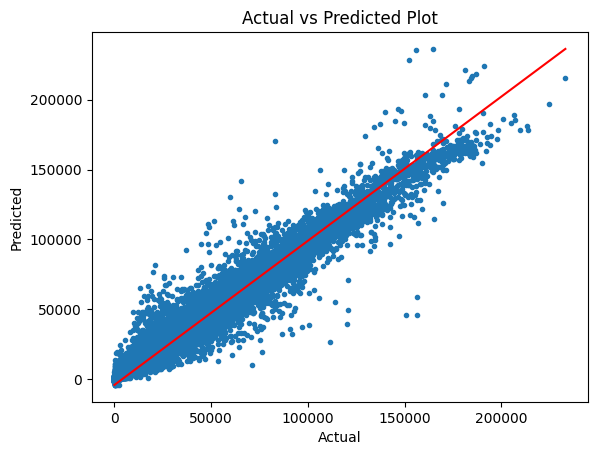

In [44]:
plt.scatter(y_test, y_pred, marker=".")
plt.plot([y_test.min(), y_test.max()], [y_pred.min(), y_pred.max()], color='Red')
plt.title("Actual vs Predicted Plot")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [45]:
residual = y_test - y_pred

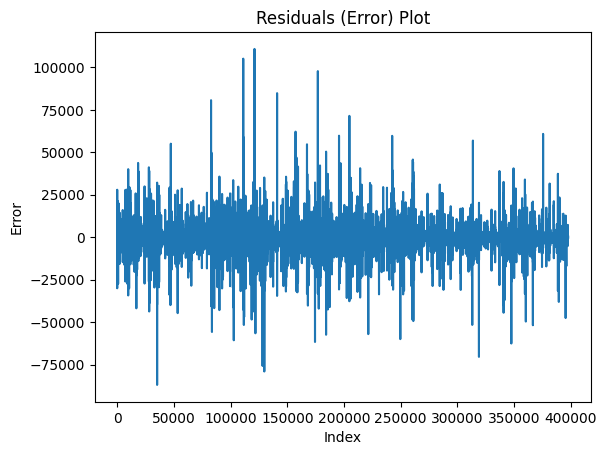

In [46]:
plt.plot(residual.index, residual.values)
plt.title("Residuals (Error) Plot")
plt.xlabel("Index")
plt.ylabel("Error")
plt.show()

In [47]:
importance = pd.DataFrame({
    "Features":X_train.columns,
    "Importance":model.feature_importances_
})

In [48]:
importance = importance.sort_values(by="Importance", ascending=True)

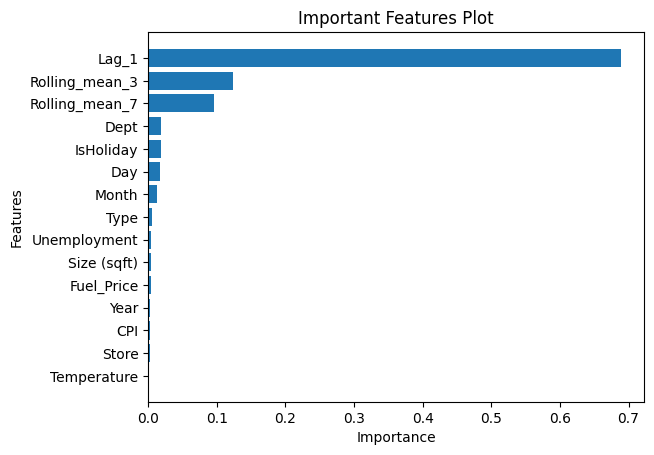

In [49]:
plt.barh(importance["Features"], importance["Importance"])
plt.title("Important Features Plot")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [50]:
import joblib

In [51]:
joblib.dump(model, "XGBRegressor.pkl")
joblib.dump(le, "LabelEncoder.pkl")

['LabelEncoder.pkl']

In [52]:
X_train.columns

Index(['Store', 'Dept', 'Day', 'Month', 'Year', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment', 'Type', 'Size (sqft)',
       'Rolling_mean_3', 'Rolling_mean_7', 'Lag_1'],
      dtype='object')